# 03 Soils and Grazing Capacity

**Project:** Pine Ridge Bison Habitat Suitability Analysis  
**BHSI Component:** Soils (20% weight)  
**Data Source:** USDA gSSURGO via SoilDataAccess
Developed by: Lilly Jones, PhD, Daear Consulting LLC                                                                               
Developed for: Oglala Lakota College                                                                                            
Funding: This material was developed as part of a project funded by the USDA National Institute of Food and Agriculture (NIFA).                       
Project role: Daear Consulting LLC developed the geospatial code, workflows, and documentation under contract to Oglala Lakota College.                                                                           
License: Apache License 2.0 (code; review of other materials is pending)                                                            

## Data Sovereignty and Governance (draft under review)
This repository contains workflows developed for use in support of Oglala Lakota College and Oglala Sioux Tribe–related research, education, and data activities. Public availability of code or documentation does not imply that Tribal data, knowledge, or derived information are open or unrestricted. Use of Tribal data and knowledge remains subject to applicable Tribal governance, permissions, protocols, and data sovereignty requirements.

## Why Soils Matter for Bison Habitat

Soils determine how productive the land can be over the long term.
The USDA gSSURGO database includes **non-irrigated land capability class**
and **grazing capacity** estimates (Animal Unit Months per acre) that
reflect each soil map unit's sustained productive potential under
proper grazing management.

For bison restoration, soils quality determines:
- How large a herd the land can support without degradation
- Whether a given area can economically sustain a bison program
- Where vegetation restoration investment will yield the best return

## Land Capability Classes

The USDA non-irrigated land capability classification (I–VIII) reflects
the land's ability to sustain agricultural use. For grazing:
- **Class I–II:** High capability: deep, well-drained soils, minimal limitations
- **Class III–IV:** Moderate capability: some limitations (slope, erosion risk)
- **Class V–VI:** Limited capability: rangeland, not suitable for cultivation
- **Class VII–VIII:** Severe limitations: rough, rocky, or highly eroded land

Bison can graze on Class V–VI land that cattle operations avoid,
which is one reason bison restoration can work on lands unsuitable
for commercial cattle ranching.

## Learning Objectives

By the end of this notebook, learners will be able to:

- distinguish tabular context from spatial patch evidence
- explain why a uniform score cannot rank locations
- inspect soil attributes and missingness

## Prerequisites and Timing

Allow 75-100 minutes. Activate the project environment, read the draft governance statement, and complete the preceding notebook where applicable. Work in pairs and rotate analyst, data-steward, skeptic, and documentarian roles.

## Governance Checkpoint

This notebook uses public data describing Oglala Lakota lands and ecological context. Public availability does not authorize every interpretation or release. Do not add restricted data, precise sensitive locations, tenure information, or community knowledge. Outputs remain educational screening products pending the appropriate OLC/OST review.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT/"src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from shapely.geometry import mapping

from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED,
    PINE_RIDGE_BBOX, CACHE_DIR, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import load_ssurgo_grazing_capacity
from src.raster_utils import normalize_0_1, align_raster_to_template
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

TEMPLATE_PATH = CACHE_DIR/"template_30m_albers.tif"
assert TEMPLATE_PATH.exists(), "Run notebook 01 first."
pine_ridge = gpd.read_file(OUTPUTS_DIR/"pine_ridge_boundary.geojson")
print("Setup complete.")

Setup complete.


In [2]:
# Print the data sovereignty statement at the top of every notebook
print_data_acknowledgment(source_keys=["gssurgo"])


PINE RIDGE BISON HABITAT ANALYSIS: DRAFT DATA GOVERNANCE ACKNOWLEDGMENT
This public-data analysis describes the Pine Ridge Census statistical area
and ecological context. Cultural wording, terminology for Pte Oyate, and the
applicable governance frameworks remain pending OLC/OST review.

Results should be understood as one input into a land management
conversation, not as a determination of where bison belong.
The repository does not determine where bison belong or authorize action.

FRAMEWORKS UNDER CONSIDERATION (NAMING DOES NOT IMPLY LOCAL ADOPTION):

CARE   : Analysis must deliver Collective Benefit to the Oglala Lakota
  community, respect their Authority to Control land use decisions,
  uphold Responsibility to the community throughout the research process,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical practices; it does not determine 

## Load gSSURGO Soil Data

In [3]:
soil_df = load_ssurgo_grazing_capacity(bbox=PINE_RIDGE_BBOX)

if soil_df.empty:
    print("gSSURGO data not available. Falling back to uniform score.")
    SOILS_AVAILABLE = False
else:
    SOILS_AVAILABLE = True
    print(f"Soil map units: {len(soil_df):,}")
    print(f"Columns: {soil_df.columns.tolist()}")
    print()
    print(soil_df.head(6).to_string(index=False))

Querying gSSURGO grazing capacity via SoilDataAccess...
gSSURGO data not available. Falling back to uniform score.


In [4]:
CAP_CLASS_SCORES = {
    "1": 1.00, "I":   1.00,
    "2": 0.90, "II":  0.90,
    "3": 0.75, "III": 0.75,
    "4": 0.60, "IV":  0.60,
    "5": 0.55, "V":   0.55,
    "6": 0.50, "VI":  0.50,
    "7": 0.20, "VII": 0.20,
    "8": 0.05, "VIII":0.05,
}

if SOILS_AVAILABLE and "nonirr_cap_cl" in soil_df.columns:
    soil_df["suit_score"] = (
        soil_df["nonirr_cap_cl"]
        .str.strip()
        .map(CAP_CLASS_SCORES)
        .fillna(0.35)
    )
    print("CAPABILITY CLASS SUITABILITY SCORES:")
    summary = (
        soil_df.groupby("nonirr_cap_cl")["suit_score"]
        .agg(["count","first"])
        .rename(columns={"count":"n_units","first":"score"})
        .sort_values("score", ascending=False)
    )
    print(summary.to_string())
else:
    print("Using fallback uniform score.")

Using fallback uniform score.


## Build Soils Suitability Raster

In [5]:
with rasterio.open(TEMPLATE_PATH) as tmpl:
    tmpl_data      = tmpl.read(1)
    tmpl_profile   = tmpl.profile.copy()
    tmpl_transform = tmpl.transform
    tmpl_shape     = (tmpl.height, tmpl.width)

soil_suit_path = OUTPUTS_DIR/"bhsi_soils.tif"

# Use mean capability score as uniform raster (spatial WFS often unavailable)
# For production: download MUPOLYGON from Web Soil Survey and rasterize
if SOILS_AVAILABLE and "suit_score" in soil_df.columns:
    uniform_score = float(soil_df["suit_score"].mean())
    print(f"Mean capability class score: {uniform_score:.3f}")
else:
    uniform_score = 0.50
    print(f"Fallback uniform score: {uniform_score:.3f}")

soil_raster = np.where(
    ~np.isnan(tmpl_data), uniform_score, np.nan
).astype(np.float32)

with rasterio.open(soil_suit_path, "w", **tmpl_profile) as dst:
    dst.write(soil_raster, 1)

print(f"Soils raster saved: outputs/bhsi_soils.tif")
print()
print("NOTE: A spatial gSSURGO raster would show variation across map units.")
print("A uniform score is demonstration-only and is rejected by notebook 07 because it cannot distinguish patches.")
print("Refine using MUPOLYGON from: https://websoilsurvey.sc.egov.usda.gov/")

Fallback uniform score: 0.500
Soils raster saved: outputs/bhsi_soils.tif

NOTE: A spatial gSSURGO raster would show variation across map units.
A uniform score is demonstration-only and is rejected by notebook 07 because it cannot distinguish patches.
Refine using MUPOLYGON from: https://websoilsurvey.sc.egov.usda.gov/


## Visualization

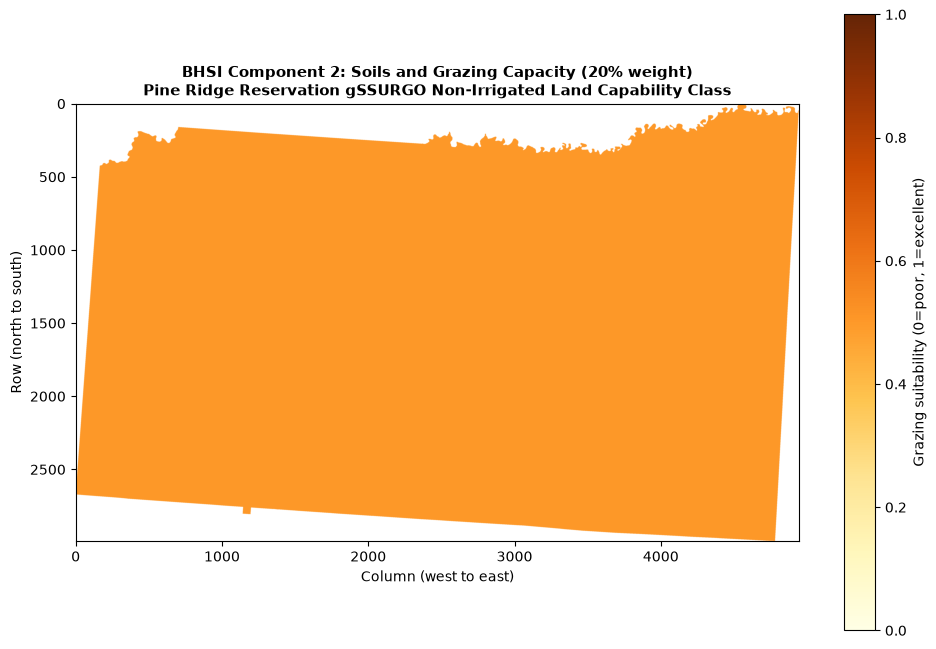

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(soil_raster, cmap="YlOrBr", vmin=0, vmax=1, origin="upper")
plt.colorbar(im, ax=ax,
             label="Grazing suitability (0=poor, 1=excellent)", shrink=0.8)
ax.set_title(
    "BHSI Component 2: Soils and Grazing Capacity (20% weight)\n"
    "Pine Ridge Reservation gSSURGO Non-Irrigated Land Capability Class",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Column (west to east)")
ax.set_ylabel("Row (north to south)")
plt.tight_layout()
fig.savefig(FIGURES_DIR/"03_soils.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
print(generate_citations(["gssurgo"]))

DATA CITATIONS

USDA gSSURGO Gridded Soil Survey Geographic Database
  https://www.nrcs.usda.gov/resources/data-and-reports/gridded-soil-survey-geographic-gssurgo-database
  Steward: USDA Natural Resources Conservation Service | License: Public domain (USDA)

Draft references under consideration: CARE | FAIR | IEEE 2890-2025 | Local Contexts | OCAP®
Naming a framework does not imply OST or OLC adoption; see documents/data_sovereignty.md.
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/


## Learner Checkpoint

Demonstrate why a uniform layer has zero spatial variation and explain why notebook 07 rejects it.

## Interpretation Protocol

Separate **observation** (what the public data and computation show) from **interpretation** (a plausible explanation), **additional evidence** (literature, field observation, local expertise, or validation needed), and **decision authority** (who may approve release, parameters, priorities, or action). Do not convert a class, score, threshold, scenario, or connected region into a cultural, biological, management, or policy conclusion.

## Contribution Activity

Improve one attribute definition, unit, crosswalk rationale, or fallback warning. Review the change with a partner and record what became clearer or more defensible.

## Evidence Record and Next Step

Record one regenerated result, source and scale, transformation, assumption, limitation, and question requiring more evidence or local knowledge. Proceed to the next numbered notebook.